In [2]:
import requests
from bs4 import BeautifulSoup
import re
#import selenium
import time
import pandas as pd
import numpy as np

import string
import nltk
nltk.download('punkt') # you will probably need to do this
nltk.download('wordnet') # and this
nltk.download('stopwords') # aand this
nltk.download('averaged_perceptron_tagger')


from sklearn.model_selection import cross_val_score
from sklearn import metrics
from sklearn.linear_model import LogisticRegression

# for vectorization 

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error



import warnings
warnings.filterwarnings('ignore')


from nltk.stem import WordNetLemmatizer
lmtzr = WordNetLemmatizer()

from sklearn.model_selection import KFold




[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Unzipping corpora/wordnet.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


In [3]:
from google.colab import drive
drive.mount('/drive')


Mounted at /drive


In [6]:


# define our URL
#obtype = "economist"
#location = "United+States"
#page = "10" #starting from page 1 = 0, entire length is "160" so 17 pages
#url = "https://www.indeed.com/jobs?q=Analyst%20%2455%2C000&l=New%20York&start=0"
# connects to site
#response = requests.get(url,headers={"content-type":"School project", 'contactinfo':'qlr200@alumni.ku.dk'})
# parse data with BeautifulSoup
#soup = BeautifulSoup(response.text,'html') # parse the HTML
#identify articles to scrape by inspecting site
#jobtitles = soup.find_all(name="div", attrs={"class":"job_seen_beacon"}) # search for the ul node
# checking if articles match website
#jobtitles
url = 'https://www.indeed.com/jobs?q=economics&l=United%20States&start='

pages = np.arange(0,1000,10)
titlesa = []
paya = []
descra = []
company = []
loc = []

#Iterating through all pages.
for page in pages:
  page = requests.get(url+str(page),headers={"content-type":"School project", 'contactinfo':'qlr200@alumni.ku.dk'})
  soup = BeautifulSoup(page.text, "html.parser")
  jobs = soup.find_all(name="div", attrs={"class":"job_seen_beacon"})

  for div in jobs:
#Company hiring
    aComp="-"
    for a in div.find_all(name="span", attrs={"class":"companyName"}):
      try:
        aComp=a.string
      except:
        print('exception comp')
        pass 
    company.append(a.string)
#Job title   
    for title in div.find_all(name="span"):
      try:
        job2 = title['title']
      except:
        pass
    titlesa.append(job2)
#salary of job posting if given
    pay = "0"  
    for salary in div.find_all('span',{'class':'salary-snippet'}):
      try:
        pay = salary.string
      except:
        print("exception pay")
        pass
    paya.append(pay)
#description of job 
    aDescr = ''
    descri = div.find_all(name='div',attrs={"class":"job-snippet"})
    for descriptions in descri[0].find_all(name='li'):
      aDescr=aDescr+descriptions.getText()+'-'
    descra.append(aDescr)
#Location of job
    aloc = ''
    for location in div.find_all('div', {'class':'companyLocation'}):
      try:
        aloc = location.text
      except:
        pass
    loc.append(aloc)

#for the company name is in span tag with class=companyName
# identifying how to find an url from an article



print(len(titlesa),len(paya),len(descra), len(company), len(loc))


1419 1419 1419 1419 1419


In [8]:
from google.colab import drive
drive.mount('/drive')


Mounted at /drive


### **Gem koden på jeres eget drev**

In [9]:

data = pd.DataFrame({'Job Title':titlesa, 'Pay':paya, 'Description':descra, 'Company':company, 'Location': loc})
data.to_csv('/drive/My Drive/jobdata_file.csv')

In [42]:
data = pd.read_csv('/drive/My Drive/jobdata_file.csv')

In [43]:
data['Pay'].value_counts()

0                             1049
$60,000 - $80,000 a year         5
$50,000 - $60,000 a year         5
$45,000 - $100,000 a year        4
$17.10 - $19.80 an hour          4
                              ... 
$43,037 - $47,340 a year         1
$46,856 - $62,480 a year         1
$67,000 - $97,900 a year         1
$103,690 - $172,500 a year       1
$95,000 - $115,000 a year        1
Name: Pay, Length: 248, dtype: int64

In [44]:

data['Pay'] = data['Pay'].str.replace('From','')
data['Pay'] = data['Pay'].str.replace('$','')
data['Pay'] = data['Pay'].str.replace(',','')
data['Pay'] = data['Pay'].str.replace('Up to','')
data['Pay'] = data['Pay'].str.replace('per','')
data['Pay'] = data['Pay'].str.replace('contact','')
data['Pay'] = data['Pay'].str.replace('per','')
data['Pay'] = data['Pay'].str.replace('contract','')

data['og_pay_period'] = np.nan

data.loc[data['Pay'].str.contains('year'),'og_pay_period'] = 'year'
data.loc[data['Pay'].str.contains('month'),'og_pay_period'] = 'month'
data.loc[data['Pay'].str.contains('hour'),'og_pay_period'] = 'hour'

salary_data = data[data['Pay'] != '0']
#removing all rows in salary data from scrape data, and converting #all “Nothing_found” values to NaN, so that float salary values can #be easily reintegrated later

data = data[~data.isin(salary_data)].dropna(how='all')
data['Pay'].replace('0',np.nan, inplace=True)
data['Pay'].astype('float')


1      NaN
5      NaN
6      NaN
8      NaN
9      NaN
        ..
1411   NaN
1415   NaN
1416   NaN
1417   NaN
1418   NaN
Name: Pay, Length: 1049, dtype: float64

In [45]:
salary_data

,Unnamed: 0,Job Title,Pay,Description,Company,Location,og_pay_period
0,0,Health Economics Writer/Researcher,65000 a year,Experience developing and/or validating econom...,"IVI Foundation, Inc",Remote,year
2,2,Economist,122530 - 159286 a year,"Degree: economics, that included at least 21 s...",US Environmental Protection Agency,"Washington, DC•Temporarily Remote",year
3,3,Faculty-Adjunct-Online-Economics,3900 - 4700 a month,Minimum of a master's degree in economics or a...,Johnson & Wales University,"Providence, RI 02903 (Downtown area)",month
4,4,Investment Analyst,45000 - 100000 a year,"Assist Investment Team with research, collecti...",Pensionmark Financial Group,Remote,year
7,7,Retail Pricing Analyst,60000 a year,Understanding of financial and economic princi...,Lume Cannabis CO,"Troy, MI•Remote",year
...,...,...,...,...,...,...,...
1408,1408,Insurance Sales Agent,35000 - 36000 a year,"In addition to direct-to-consumer marketing, w...",Goosehead Insurance,"Towson, MD 21286",year
1410,1410,Retail Pricing Analyst,60000 a year,Develop and implement category pricing strateg...,SpartanNash,"Byron Center, MI 49315•Temporarily Remote",year
1412,1412,Market Research - Phone Surveyor,16.50 an hour,Annual pay rate increases and regular cost of ...,Kelly,"North Chelmsford, MA 01863•Temporarily Remote",hour
1413,1413,Business Analyst,60000 - 80000 a year,The ideal candidate will be able to provide gu...,Meador Staffing Services,"Houston, TX 77024 (Greater Memorial area)",year


In [46]:
salary_data2 = salary_data.copy()

salary_data2

year_sal = salary_data2[salary_data2['Pay'].str.contains('year')]
month_sal = salary_data2[salary_data2['Pay'].str.contains('month')]
hour_sal = salary_data2[salary_data2['Pay'].str.contains('hour')]



year_sal['Pay'] = year_sal['Pay'].str.replace(' a year','')
month_sal['Pay'] = month_sal['Pay'].str.replace(' a month','')
hour_sal['Pay'] = hour_sal['Pay'].str.replace(' an hour','')
hour_sal['Pay'] = hour_sal['Pay'].str.replace(' hour','')




In [47]:
def ave_sal(i):
  try:
    splt = i.split('-',1)
    first = float(splt[0])
    second =  float(splt[1])
    return (first+second)/2
  except:
    return float(i)


year_sal['Pay'] = year_sal['Pay'].apply(ave_sal)

month_sal['Pay'] = (month_sal['Pay'].apply(ave_sal))*12
hour_sal['Pay'] = hour_sal['Pay'].apply(ave_sal)*1801




In [48]:
#Combine to one DataFrame 

combined = pd.concat([year_sal,month_sal,hour_sal],axis = 0)
df = pd.concat([data,combined], axis = 0)
df.drop_duplicates(keep = False, inplace = True)

df['Location'] = df['Location'].str.split(' \d', expand = True, n = 1)

#Reorganisize to have pay on RHS
scraped = df[['Job Title','Description','Company','Location','Pay','og_pay_period']]
scraped2 = scraped['Pay'].sort_values()

,Job Title,Description,Company,Location,Pay,og_pay_period
1,Economics Adjuncts,Individuals needed to teach 2-3 face-to-face o...,UNC Pembroke,"Pembroke, NC",NaN,NaN
5,Tenure-track positions in Economics,"The positions are open rank/open field, althou...",Bates College,"Lewiston, ME",NaN,NaN
6,Research Data Analyst,"Relevant experience in economics, health econo...",Stanford University,"Stanford, CA",NaN,NaN
8,Research Data Analyst Associate,The position is a good opportunity for those c...,Northwestern University,"Evanston, IL",NaN,NaN
9,Undergraduate Grader for Economics Courses,The ASR includes crime statistics and institut...,Penn State University,"University Park, PA",NaN,NaN
...,...,...,...,...,...,...
1382,Staff Accountant,If you're looking to build your career in acco...,Robert Half,"Miami, FL",33228.45,hour
1390,Credit Manager Colfax WA,"Reporting to the President, the Credit Manager...",The McGregor Company,"Spokane, WA",70239.00,hour
1393,Staff Accountant,Responsibilities held by the Staff Accountant ...,Robert Half,"Miami, FL",33228.45,hour
1412,Market Research - Phone Surveyor,Annual pay rate increases and regular cost of ...,Kelly,"North Chelmsford, MA",29716.50,hour


##Gem og load fil

In [132]:
#scraped.to_csv('/drive/My Drive/scraped.csv')


scraped = pd.read_csv('/drive/My Drive/scraped.csv', index_col=0)
scraped.index = np.arange(1, len(scraped)+1)


In [133]:
scraped = scraped.dropna(subset = ['Description'])
scraped['Pay'].describe()

count    3.590000e+02
mean     8.234796e+04
std      6.640543e+04
min      1.718400e+04
25%      4.952750e+04
50%      6.753750e+04
75%      1.022500e+05
max      1.035575e+06
Name: Pay, dtype: float64

In [134]:
#Lower case
scraped['Job Title'] = scraped['Job Title'].str.lower()
scraped['Description'] = scraped['Description'].str.lower()
scraped['Company'] = scraped['Company'].str.lower()
scraped['Location'] = scraped['Location'].str.lower()


In [7]:
scraped.tail(4)

,Job Title,Description,Company,Location,Pay,og_pay_period
1412,credit manager colfax wa,"reporting to the president, the credit manager...",the mcgregor company,"spokane, wa",70239.00,hour
1413,staff accountant,responsibilities held by the staff accountant ...,robert half,"miami, fl",33228.45,hour
1414,market research - phone surveyor,annual pay rate increases and regular cost of ...,kelly,"north chelmsford, ma",29716.50,hour
1415,market analyst ii,"experience in business, finance, accounting, o...",bepc inc,"princeton, nj",60135.39,hour


Salary median:  67537.5
Salary mean:  82347.95639275765
Salary max:  1035575.0


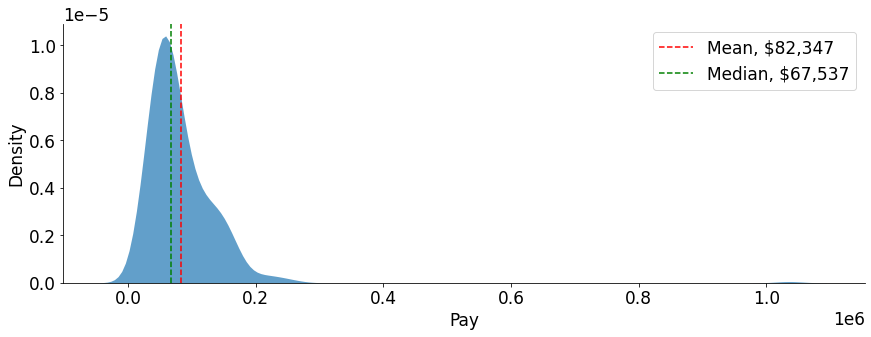

In [135]:
#Salary Distribution plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 17

print('Salary median: ',(scraped['Pay'].median()))
print('Salary mean: ',(scraped['Pay'].mean()))
print('Salary max: ',(scraped['Pay'].max()))


sal_distribution = scraped[scraped["Pay"].notnull()]


g = sns.displot(data=sal_distribution['Pay'], kind="kde", palette="crest", fill = True,alpha=0.7, linewidth=0,)
g.fig.set_figwidth(15)
g.fig.set_figheight(5)
plt.axvline(sal_distribution['Pay'].mean(), color = 'r', ls = 'dashed', label = 'Mean, $82,347')
plt.axvline(sal_distribution['Pay'].median(), color = 'g', ls = 'dashed', label = 'Median, $67,537')
plt.legend()

In [136]:
def convert(s):
  return str(s)

def removePunctuation (word):
    return re.sub("[^\w\s\-\'\’\ -]", "", word)

from string import punctuation
def remove_punctuation(s):
    global punctuation
    for p in punctuation:
        s = s.replace(p, '')
    return s

stop_words_list = nltk.corpus.stopwords.words("english")

def removestarwords(s):
  return re.sub('[^\s\]*[\*]+[^\s]*','',s)

def remove_stopwords(s):
    global stop_words_list
    s = nltk.word_tokenize(s)
    s = " ".join([w for w in s if w not in stop_words_list])
    return s

In [137]:

#converting all text data to string
scraped['Job Title'] = scraped['Job Title'].map(convert)
scraped['Description'] = scraped['Description'].map(convert)
scraped['Company'] = scraped['Company'].map(convert)
scraped['Location'] = scraped['Location'].map(convert)

#Removing punctuations from Job Title and location
scraped['Job Title'] = scraped['Job Title'].map(removePunctuation)#From lecture module
scraped['Job Title'] = scraped['Job Title'].map(remove_punctuation)#backup as all punctuations didnt get removed
scraped['Job Title'] = scraped['Job Title'].map(remove_stopwords)#backup as all punctuations didnt get removed



scraped['Location'] = scraped['Location'].map(removePunctuation)#From lecture module
scraped['Location'] = scraped['Location'].map(remove_punctuation)#backup as all punctuations didnt get removed

#Removing ... from Description
scraped['Description'] = scraped['Description'].str.replace("…"," ")


#Removing stop words and punctuations from description and storing it in summary
scraped['summary'] = scraped['Description'].map(removePunctuation) #From lecture module
scraped['summary'] = scraped['summary'].map(remove_punctuation) #backup as all punctuations didnt get removed
scraped['summary'] = scraped['summary'].map(remove_stopwords) #stopwords
scraped['summary'] = scraped['summary'].str.replace(" ’","") #to remove annoying ' value that didnt get remove from punctuation






In [ ]:
#scraped = scraped.dropna(subset=['Description'], inplace = True)


In [138]:
scraped

,Job Title,Description,Company,Location,Pay,og_pay_period,summary
1,economics adjuncts,individuals needed to teach 2-3 face-to-face o...,unc pembroke,pembroke nc,NaN,NaN,individuals needed teach 23 facetoface online ...
2,tenuretrack positions economics,"the positions are open rank/open field, althou...",bates college,lewiston me,NaN,NaN,positions open rankopen field although especia...
3,research data analyst,"relevant experience in economics, health econo...",stanford university,stanford ca,NaN,NaN,relevant experience economics health economics...
4,research data analyst associate,the position is a good opportunity for those c...,northwestern university,evanston il,NaN,NaN,position good opportunity considering graduate...
5,undergraduate grader economics courses,the asr includes crime statistics and institut...,penn state university,university park pa,NaN,NaN,asr includes crime statistics institutional po...
...,...,...,...,...,...,...,...
1411,staff accountant,if you're looking to build your career in acco...,robert half,miami fl,33228.45,hour,youre looking build career accounting theres c...
1412,credit manager colfax wa,"reporting to the president, the credit manager...",the mcgregor company,spokane wa,70239.00,hour,reporting president credit manager responsible...
1413,staff accountant,responsibilities held by the staff accountant ...,robert half,miami fl,33228.45,hour,responsibilities held staff accountant include...
1414,market research phone surveyor,annual pay rate increases and regular cost of ...,kelly,north chelmsford ma,29716.50,hour,annual pay rate increases regular cost living ...


In [139]:
scraped['summary'] = scraped['summary'].map(remove_stopwords) #stopwords

scraped

,Job Title,Description,Company,Location,Pay,og_pay_period,summary
1,economics adjuncts,individuals needed to teach 2-3 face-to-face o...,unc pembroke,pembroke nc,NaN,NaN,individuals needed teach 23 facetoface online ...
2,tenuretrack positions economics,"the positions are open rank/open field, althou...",bates college,lewiston me,NaN,NaN,positions open rankopen field although especia...
3,research data analyst,"relevant experience in economics, health econo...",stanford university,stanford ca,NaN,NaN,relevant experience economics health economics...
4,research data analyst associate,the position is a good opportunity for those c...,northwestern university,evanston il,NaN,NaN,position good opportunity considering graduate...
5,undergraduate grader economics courses,the asr includes crime statistics and institut...,penn state university,university park pa,NaN,NaN,asr includes crime statistics institutional po...
...,...,...,...,...,...,...,...
1411,staff accountant,if you're looking to build your career in acco...,robert half,miami fl,33228.45,hour,youre looking build career accounting theres c...
1412,credit manager colfax wa,"reporting to the president, the credit manager...",the mcgregor company,spokane wa,70239.00,hour,reporting president credit manager responsible...
1413,staff accountant,responsibilities held by the staff accountant ...,robert half,miami fl,33228.45,hour,responsibilities held staff accountant include...
1414,market research phone surveyor,annual pay rate increases and regular cost of ...,kelly,north chelmsford ma,29716.50,hour,annual pay rate increases regular cost living ...


In [103]:
corpus = " ".join(scraped['summary'].tolist())

tokens = nltk.word_tokenize(corpus)
print(len(tokens))

freqdist = nltk.FreqDist(tokens)

19393


The value of theta obtained is: [-1.03683269]


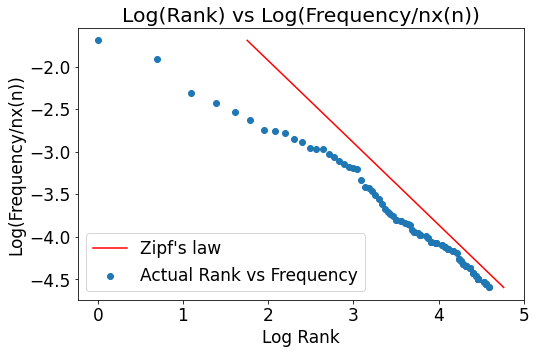

In [104]:
top_words = []
for key, value in freqdist.items():
  top_words.append((key,value))

# sort the list by the top frequencies
top_words = sorted(top_words, key = lambda x:x[1], reverse = True)

# keep top 100 words only
top_words = top_words[:100]

# Keep the frequencies only from the top word series
top_word_series = pd.Series([w for (v,w) in top_words])
top_word_series[:5]

# get actual ranks of these words - wherever we see same frequencies, we give same rank
word_ranks = top_word_series.rank(method = 'min', ascending = False)

# Get the value of the denominator n*x_n
denominator = max(word_ranks)*min(top_word_series)

# Y variable is the log of word ranks and X is the word frequency divided by the denominator
# above
Y = np.array(np.log(word_ranks))
X = np.array(np.log(top_word_series/denominator))

# fit a linear regression to these, we dont need the intercept!
from sklearn import linear_model
reg_model = linear_model.LinearRegression(fit_intercept = False)
reg_model.fit(Y.reshape(-1,1), X)
print("The value of theta obtained is:",reg_model.coef_)

# make a plot of actual rank obtained vs theoretical rank expected
plt.figure(figsize = (8,5))
plt.scatter(Y, X, label = "Actual Rank vs Frequency")
plt.title('Log(Rank) vs Log(Frequency/nx(n))')
plt.xlabel('Log Rank')
plt.ylabel('Log(Frequency/nx(n))')

plt.plot(reg_model.predict(X.reshape(-1,1)), X, color = 'red', label = "Zipf's law")
plt.legend()

In [105]:
corpus2 = " ".join(scraped['summary'].tolist())

tokens2 = nltk.word_tokenize(corpus2)
print(len(tokens2))

corpus3 = " ".join(scraped['Job Title'].tolist())

tokens3 = nltk.word_tokenize(corpus3)
print(len(tokens3))

19393
5076


In [23]:
print(corpus3)

economics adjuncts tenuretrack positions in economics research data analyst research data analyst associate undergraduate grader for economics courses financial analyst new york games analyst data science visualization manager undergraduate grader for economics courses games analyst equity research associate  us banks financial analyst healthcare economics specialist ii research assistant remote mortgage modeler  analyst energy trader energy markets economist financial analyst new york assistant professor economics tenure track economics instructor assistant professor economics  the university of texas at el paso economic policy staffer economics adjunct nyc financial analyst fpa burbank economic research analyst junior trader statistics analyst ii data analyst remote social insights analyst statistical assistant ground teaching assistant  economics  traditional campus  colangelo college of business analyst life sciences remote economic analyst middle office analyst data scientist  eco

In [106]:
lemmatized_tokens = [lmtzr.lemmatize(token) for token in tokens2]

# word frequencies for the lemmatized tokens
fd = nltk.FreqDist(lemmatized_tokens)

# get the top words
top_words = []
for key, value in fd.items():
    top_words.append((key, value))

# sort the list by the top frequencies
top_words = sorted(top_words, key = lambda x:x[1], reverse = True)

# keep top 10 words only
top_words = top_words[:100]

top_words

[('economics', 511),
 ('degree', 413),
 ('business', 280),
 ('finance', 245),
 ('data', 221),
 ('analyst', 207),
 ('bachelor', 203),
 ('related', 179),
 ('financial', 176),
 ('pricing', 173),
 ('economic', 160),
 ('research', 157),
 ('team', 153),
 ('responsible', 144),
 ('management', 143),
 ('field', 142),
 ('statistic', 142),
 ('experience', 137),
 ('analysis', 130),
 ('support', 126),
 ('accounting', 119),
 ('market', 111),
 ('position', 97),
 ('role', 95),
 ('work', 94),
 ('science', 87),
 ('development', 84),
 ('manager', 79),
 ('product', 72),
 ('year', 71),
 ('company', 70),
 ('mathematics', 70),
 ('program', 70),
 ('customer', 70),
 ('relevant', 68),
 ('service', 68),
 ('candidate', 67),
 ('marketing', 66),
 ('quantitative', 65),
 ('client', 64),
 ('administration', 62),
 ('planning', 61),
 ('analytics', 60),
 ('health', 59),
 ('master', 59),
 ('including', 58),
 ('risk', 57),
 ('operation', 56),
 ('policy', 55),
 ('report', 55),
 ('looking', 55),
 ('develop', 54),
 ('seeking'

In [107]:
lemmatized_tokens2 = [lmtzr.lemmatize(token) for token in tokens3]

# word frequencies for the lemmatized tokens
fd = nltk.FreqDist(lemmatized_tokens2)

# get the top words
top_words2 = []
for key, value in fd.items():
    top_words2.append((key, value))

# sort the list by the top frequencies
top_words2 = sorted(top_words2, key = lambda x:x[1], reverse = True)


# keep top 10 words only
top_words2 = top_words2[:28]

top_words2

[('analyst', 637),
 ('pricing', 201),
 ('research', 175),
 ('market', 148),
 ('manager', 132),
 ('senior', 117),
 ('economics', 116),
 ('associate', 116),
 ('data', 108),
 ('financial', 104),
 ('business', 85),
 ('director', 55),
 ('specialist', 49),
 ('investment', 46),
 ('assistant', 44),
 ('economist', 43),
 ('analytics', 42),
 ('finance', 41),
 ('consultant', 40),
 ('coordinator', 38),
 ('economic', 37),
 ('operation', 36),
 ('strategy', 36),
 ('risk', 36),
 ('development', 35),
 ('management', 35),
 ('sr', 32),
 ('credit', 31)]

In [140]:
scraped['Location'] = scraped['Location'].map(remove_punctuation)
scraped['Location'] = scraped['Location'].str.split(' \d', expand = True, n = 1)
scraped['Location']

1               pembroke nc
2               lewiston me
3               stanford ca
4               evanston il
5        university park pa
               ...         
1411               miami fl
1412             spokane wa
1413               miami fl
1414    north chelmsford ma
1415           princeton nj
Name: Location, Length: 1390, dtype: object

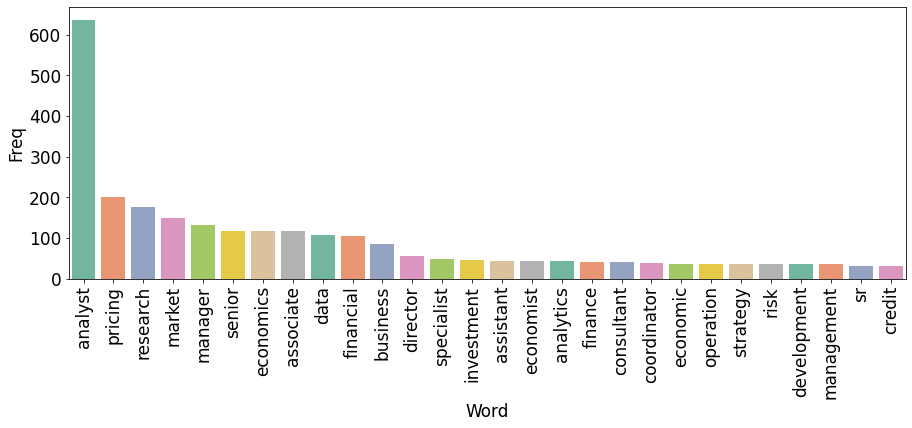

In [34]:
from wordcloud import WordCloud
#convert list to string and generate
word = pd.DataFrame(top_words2, columns = ['Word','Freq'])
fig, ax = plt.subplots(figsize=(15,5))
plt.xticks(rotation=90)
sns.barplot(x=word.Word, y=word.Freq, palette="Set2")


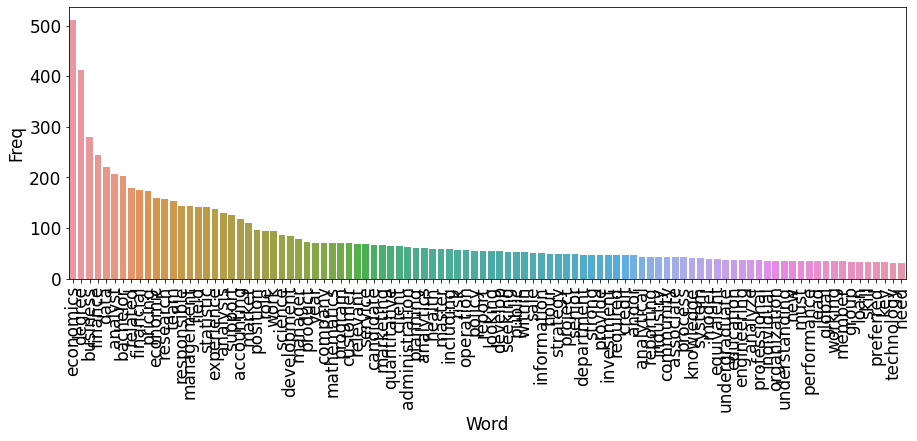

In [35]:
#convert list to string and generate
word = pd.DataFrame(top_words, columns = ['Word','Freq'])
fig, ax = plt.subplots(figsize=(15,5))
plt.xticks(rotation=90)
sns.barplot(x=word.Word, y=word.Freq)


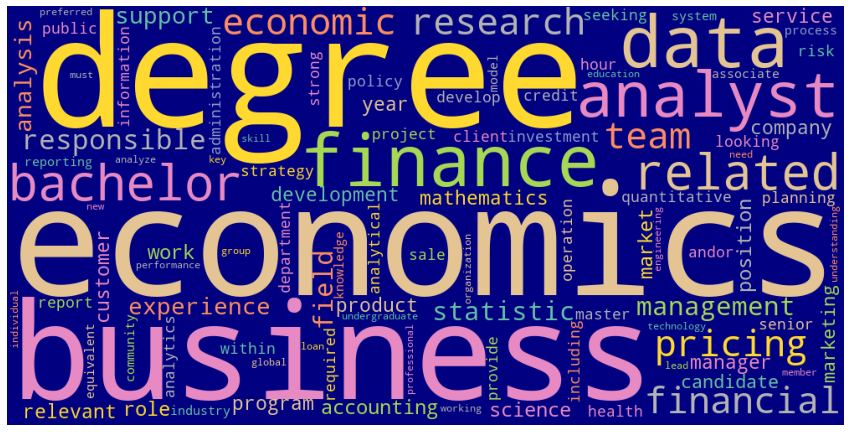

In [36]:
#convert it to dictionary with values and its occurences
from collections import Counter
word_could_dict=Counter(word.Word)
wordcloud = WordCloud(width = 1000, height = 500, background_color='navy', colormap='Set2').generate_from_frequencies(word_could_dict)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

###Modelling and prediction.
Splitting up data to only include data with salary and creating new variable with above or below median.


In [141]:
#saving scraped data after string manipulation
scraped.to_csv('/drive/My Drive/scrapedafterstring.csv')


#scraped = pd.read_csv('/drive/My Drive/scraped.csv', index_col=0)
scraped.index = np.arange(1, len(scraped)+1)

#New binary variable


scraped["above_med_sal"] = np.nan
scraped.loc[scraped["Pay"] > scraped["Pay"].median(), "above_med_sal"] = 1

scraped.loc[scraped["Pay"] <= scraped["Pay"].median(), "above_med_sal"] = 0

#Splitting up data to only include job ads with salary. 
sal_data = scraped[scraped.above_med_sal.notnull()] #as all NaN is notnull they will be removed.


In [144]:
sal_data.index = np.arange(1, len(sal_data)+1)
#Saving for exam hand in
sal_data.to_csv('/drive/My Drive/sal_data.csv')

In [143]:
#Above median salary will be the predictor and 
sal_X = sal_data.iloc[:,0:len(sal_data.columns)-1]
sal_X.iloc[:,0:len(sal_data.columns)]

sal_Y = pd.DataFrame(sal_data['above_med_sal'])

#Saving for exam hand in
sal_X.to_csv('/drive/My Drive/sal_X.csv')
sal_Y.to_csv('/drive/My Drive/sal_Y.csv')

In [128]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(sal_X, sal_Y, test_size=0.5, stratify=sal_Y, random_state=1)
X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

### Starting the analysis from words in Job Title

In [41]:
cvec = CountVectorizer(stop_words='english',ngram_range=(1, 3), min_df = 0.03)
cvec.fit(X_train['Job Title'])

#transforming job_title data into job_train
job_train = pd.DataFrame(cvec.fit_transform(X_train["Job Title"]).todense(),columns=cvec.get_feature_names())
job_test = pd.DataFrame(cvec.transform(X_test["Job Title"]).todense(),columns=cvec.get_feature_names())


In [42]:
#now scoring a logistic regression on job_train and y_train using cross_val_scores

logreg = LogisticRegression()
logreg.fit(job_train, y_train)
print("Score:", logreg.score(job_train, y_train)) 
kfold = KFold(n_splits=10, random_state=0, shuffle=True)
scores = cross_val_score(logreg, job_train, y_train, cv=kfold)
mean_scores = pd.Series(scores)
print("Cross-validated scores: Min, Mean, Max", mean_scores.min(), mean_scores.mean(), mean_scores.max())

# Predicting salaries in X_test given predictors developed with X_train
y_probs = logreg.predict(job_test)   
#generates predicted values of Y_test from X_test based off of training set.
print("Score:", logreg.score(job_test, y_test))
#Create classification and confusion matrix
# printing confusion matrix 
print(confusion_matrix(y_test, y_probs,))
#printing classification report
target_names = ['below_med', 'above_med']
print(classification_report(y_test, y_probs, target_names=target_names))



Score: 0.7150837988826816
Cross-validated scores: Min, Mean, Max 0.4444444444444444 0.5816993464052287 0.7777777777777778
Score: 0.6722222222222223
[[68 23]
 [36 53]]
              precision    recall  f1-score   support

   below_med       0.65      0.75      0.70        91
   above_med       0.70      0.60      0.64        89

    accuracy                           0.67       180
   macro avg       0.68      0.67      0.67       180
weighted avg       0.68      0.67      0.67       180



In [146]:
#Printing performace parameters.
mse_log = mean_squared_error(y_test,y_probs)
RMSE_log = np.sqrt(mean_squared_error(y_test,y_probs))
print('Mse', mse_log, 'rmse', RMSE_log)

Mse 0.37222222222222223 rmse 0.6101001739241042


In [145]:
#Running Lasso regression

lambdas = np.logspace(-4,4,20)

coefs = []
RMSE_test = []
RMSE_train = []
MSE_test = []
MSE_train = []
MAE_test = []
MAE_train = []

for a in lambdas:
  lasso = Lasso(alpha = a)
  lasso.fit(job_train,y_train)
  y_pred_test = lasso.predict(job_test)
  y_pred_train = lasso.predict(job_train)
  coefs.append(lasso.coef_)
  RMSE_test.append(np.sqrt(mean_squared_error(y_test,y_pred_test)))
  RMSE_train.append(np.sqrt(mean_squared_error(y_train,y_pred_train)))
  MSE_test.append(mean_squared_error(y_test,y_pred_test))
  MSE_train.append(mean_squared_error(y_train,y_pred_train))
  MAE_test.append(mean_absolute_error(y_test,y_pred_test))
  MAE_train.append(mean_absolute_error(y_train,y_pred_train))


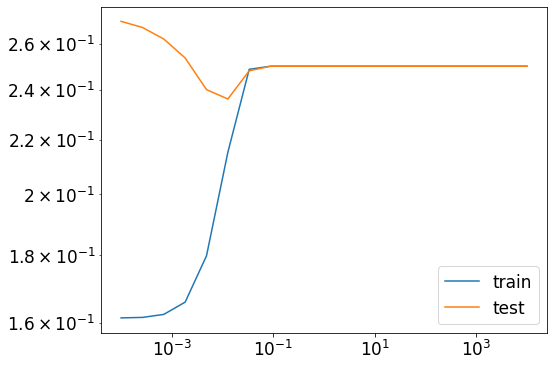

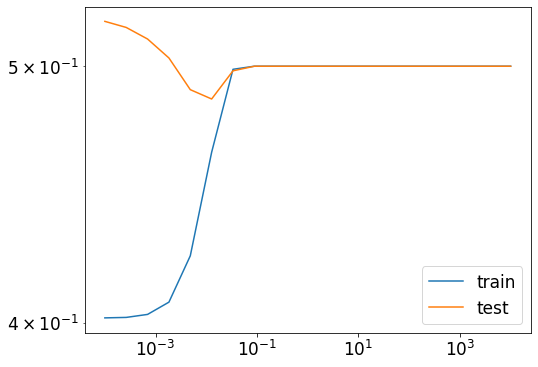

In [72]:
#Creating dataframe to visualise convergence.
df2 = pd.concat([pd.Series(RMSE_train),pd.Series(RMSE_test)],axis=1)
df23 = pd.concat([pd.Series(MSE_train),pd.Series(MSE_test)],axis=1)

#defining average function
def ave(rmse): 
  return (sum(rmse)/len(rmse))

#plotting

df23 = pd.DataFrame(df23)
df2 = pd.DataFrame(df2)


df2.columns = ['train','test']
df2 = df2.set_index(lambdas)

df23.columns = ['train','test']
df23 = df23.set_index(lambdas)


#fig, ax = plt.subplots(3,1, figsize = (15,5))
ax = df23.plot(logx=True, logy = True)
ax = df2.plot(logx=True, logy = True)


In [33]:
print('mse train',ave(MSE_train), 'RMSE train', ave(RMSE_test))

mae train 0.46602400366323493 mse train 0.22964697883826074 RMSE train 0.4850889968823077


### Random Forest classifier analysis for Job Title

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import cross_validate
import warnings
warnings.filterwarnings('ignore')

n_estimators = np.logspace(np.log10(5), np.log10(500), 20)
train_score1 = []
test_score1 = []

for estimator in n_estimators: 
    model = RandomForestClassifier(n_estimators = int(estimator)  ) 
    cv = StratifiedShuffleSplit(n_splits=20,test_size=.05,random_state=3)
    scores = cross_validate(model, job_train, y_train, cv=cv, return_train_score=True,n_jobs=-1)
    train_score1.append(np.mean(scores["train_score"]))
    test_score1.append(np.mean(scores["test_score"]))

print('Max test score: ', max(test_score1), 'Max train score: ', max(train_score1))

### Model analysis for job summary

In [129]:
#FOR DESCRIPTION
cvec2 = CountVectorizer(stop_words='english',ngram_range=(1,2), min_df = .05)
cvec2.fit(X_train['summary'])

#transforming job_title data into job_train
sum_train = pd.DataFrame(cvec2.fit_transform(X_train["summary"]).todense(),columns=cvec2.get_feature_names())
sum_test = pd.DataFrame(cvec2.transform(X_test["summary"]).todense(),columns=cvec2.get_feature_names())


In [47]:
#FOR DESCRIPTION /JOB
#now score a logistic regression on X_train and y_train using cross_val_scores
from sklearn.model_selection import cross_val_score
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(sum_train, y_train)
print("Score:", logreg.score(sum_train, y_train)) 
scores = cross_val_score(logreg, sum_train, y_train, cv=6)
print("Cross-validated scores:", scores)



# Predicting salaries in X_test given predictors developed with X_train
y_probs = logreg.predict(sum_test)   
#generates predicted values of Y_test from X_test based off of training set.
print("Score:", logreg.score(sum_test, y_test))
#Create classification and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# printing confusion matrix 
print(confusion_matrix(y_test, y_probs,))
#printing classification report
target_names = ['below_med', 'above_med']
print(classification_report(y_test, y_probs, target_names=target_names))



Score: 0.7374301675977654
Cross-validated scores: [0.5        0.5        0.73333333 0.5        0.66666667 0.4137931 ]
Score: 0.6277777777777778
[[59 32]
 [35 54]]
              precision    recall  f1-score   support

   below_med       0.63      0.65      0.64        91
   above_med       0.63      0.61      0.62        89

    accuracy                           0.63       180
   macro avg       0.63      0.63      0.63       180
weighted avg       0.63      0.63      0.63       180



In [48]:

mse_log = mean_squared_error(y_test,y_probs)
RMSE_log = np.sqrt(mean_squared_error(y_test,y_probs))
print('Mse', mse_log, 'rmse', RMSE_log)

Mse 0.37222222222222223 rmse 0.6101001739241042 mae_log 0.37222222222222223


In [130]:
#Lasso regression for job summary

lambdas = np.logspace(-4,4,20)

coefs = []
RMSE_test = []
RMSE_train = []
MSE_test = []
MSE_train = []
MAE_test = []
MAE_train = []

for a in lambdas:
  lasso = Lasso(alpha = a)
  lasso.fit(sum_train,y_train)
  y_pred_test = lasso.predict(sum_test)
  y_pred_train = lasso.predict(sum_train)
  coefs.append(lasso.coef_)
  RMSE_test.append(np.sqrt(mean_squared_error(y_test,y_pred_test)))
  RMSE_train.append(np.sqrt(mean_squared_error(y_train,y_pred_train)))
  MSE_test.append(mean_squared_error(y_test,y_pred_test))
  MSE_train.append(mean_squared_error(y_train,y_pred_train))
  MAE_test.append(mean_absolute_error(y_test,y_pred_test))
  MAE_train.append(mean_absolute_error(y_train,y_pred_train))





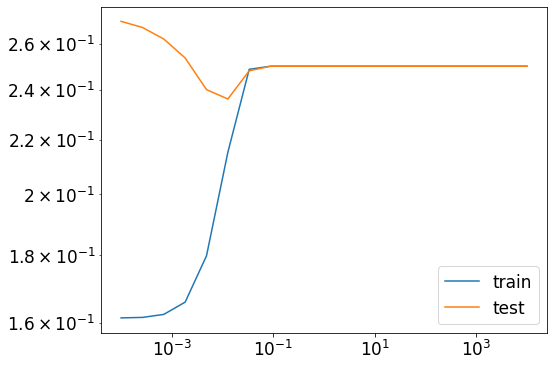

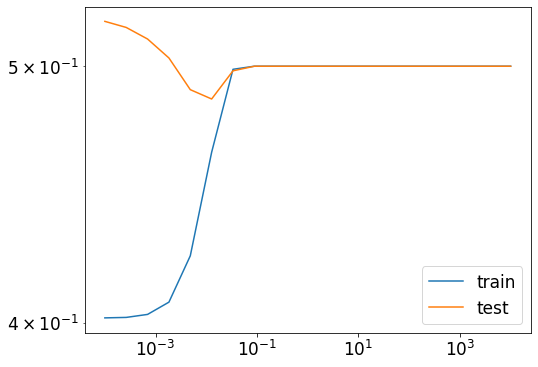

In [131]:
#Creating dataframe to visualise convergence.
df3 = pd.concat([pd.Series(RMSE_train),pd.Series(RMSE_test)],axis=1)
df32 = pd.concat([pd.Series(MSE_train),pd.Series(MSE_test)],axis=1)


#plotting

df3 = pd.DataFrame(df3)
df32 = pd.DataFrame(df32)


df3.columns = ['train','test']
df3 = df3.set_index(lambdas)

df32.columns = ['train','test']
df32 = df32.set_index(lambdas)


#fig, ax = plt.subplots(3,1, figsize = (15,5))
ax = df32.plot(logx=True, logy = True)
ax = df3.plot(logx=True, logy = True)


### Random forest classifier for job summary

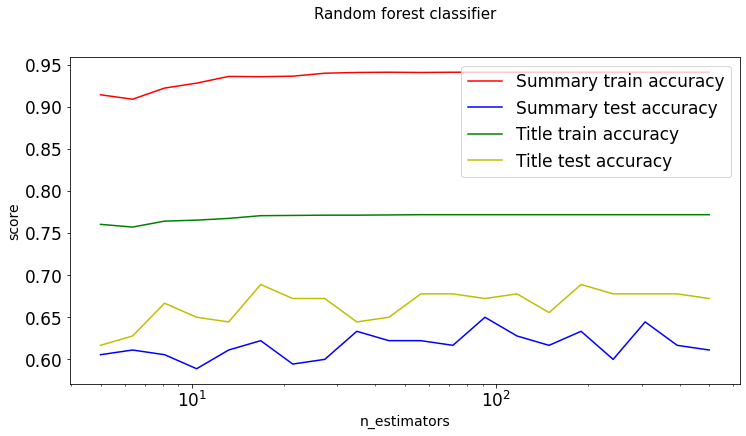

Max test score:  0.6500000000000001 Max train score:  0.9408823529411764


In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import cross_validate
import warnings
warnings.filterwarnings('ignore')

n_estimators = np.logspace(np.log10(5), np.log10(500), 20)
train_score = []
test_score = []

for estimator in n_estimators: 
    model = RandomForestClassifier(n_estimators = int(estimator)  ) 
    cv = StratifiedShuffleSplit(n_splits=20,test_size=.05,random_state=3)
    scores = cross_validate(model, sum_train, y_train, cv=cv, return_train_score=True,n_jobs=-1)
    train_score.append(np.mean(scores["train_score"]))
    test_score.append(np.mean(scores["test_score"]))


print('Max test score: ', max(test_score), 'Max train score: ', max(train_score))

### Random forest classifier plot for Title and Summary

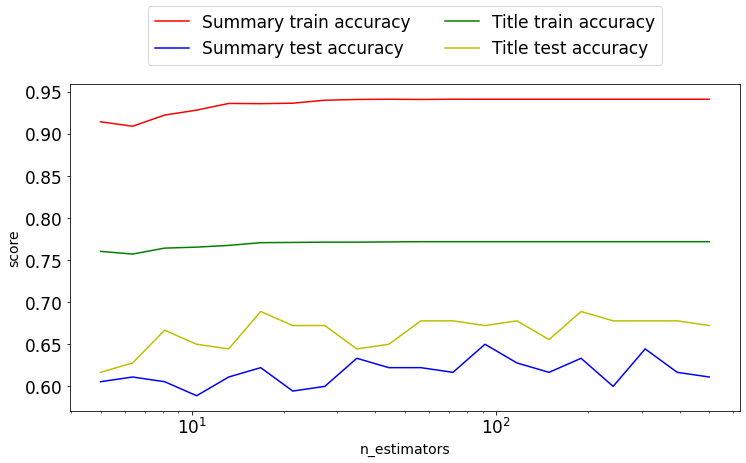

In [62]:
plt.figure(figsize=(12, 6))
plt.plot(n_estimators, train_score, label="Summary train accuracy",color='r')
plt.plot(n_estimators, test_score, label="Summary test accuracy",color='b')
plt.plot(n_estimators, train_score1, label = "Title train accuracy", color = "g")
plt.plot(n_estimators, test_score1, label = "Title test accuracy", color = "y")
plt.ylabel("score", fontsize="14")
plt.xlabel("n_estimators", fontsize="14")
plt.xscale('log')
plt.legend(loc="center", bbox_to_anchor=(0.5, 1.15), ncol=2)
plt.show()


## Code for textual analysis

### In this section the code for our textual analysis is written

In [93]:
from sklearn.naive_bayes import BernoulliNB


In [111]:
#Choose random obs. for our training set
import random


#Define 75 percentile of code
sal_perc_75 = np.percentile(sal_data['Pay'], 75)

# Create a new target variable of salary high (1) or low (0)
sal_data['Pay_high'] = np.where(sal_data['Pay'] >= sal_perc_75, 1, 0)
sal_data

,Job Title,Description,Company,Location,Pay,og_pay_period,summary,above_med_sal,Pay_high
1,health economics writerresearcher,experience developing and/or validating econom...,"ivi foundation, inc",remote,65000.00,year,experience developing andor validating economi...,0.0,0
2,economist,"degree: economics, that included at least 21 s...",us environmental protection agency,washington dctemporarily remote,140908.00,year,degree economics included least 21 semester ho...,1.0,1
3,investment analyst,"assist investment team with research, collecti...",pensionmark financial group,remote,72500.00,year,assist investment team research collection com...,1.0,0
4,retail pricing analyst,understanding of financial and economic princi...,lume cannabis co,troy miremote,60000.00,year,understanding financial economic principlesund...,0.0,0
5,economic analyst,"economic analysts assess foreign economic, tra...",central intelligence agency,washington dc,115285.00,year,economic analysts assess foreign economic trad...,1.0,1
...,...,...,...,...,...,...,...,...,...
355,staff accountant,if you're looking to build your career in acco...,robert half,miami fl,33228.45,hour,youre looking build career accounting theres c...,0.0,0
356,credit manager colfax wa,"reporting to the president, the credit manager...",the mcgregor company,spokane wa,70239.00,hour,reporting president credit manager responsible...,1.0,0
357,staff accountant,responsibilities held by the staff accountant ...,robert half,miami fl,33228.45,hour,responsibilities held staff accountant include...,0.0,0
358,market research phone surveyor,annual pay rate increases and regular cost of ...,kelly,north chelmsford ma,29716.50,hour,annual pay rate increases regular cost living ...,0.0,0


In [76]:
#Drop non unique words
sal_data.select_dtypes('object').nunique(dropna = False)


Job Title        241
Description      260
Company          228
Location         171
og_pay_period      3
summary          256
dtype: int64

In [112]:
sal_data['Pay_high'].value_counts()/len(sal_data)

0    0.749304
1    0.250696
Name: Pay_high, dtype: float64

## Bernoulli Bayes Naive Start

In [113]:
#X and y for model fitting
X = np.array(sal_data.loc[:, 'summary'])
y = np.array(sal_data.loc[:, 'Pay_high'])


In [114]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.5, random_state = 2)

model = BernoulliNB()

count_vectorizer = CountVectorizer()
X_train_counts = count_vectorizer.fit_transform(X_train)
X_test_counts = count_vectorizer.transform(X_test)

In [115]:
# Calculate the frequencies of words using the TfidfTransformer
X_train_bern = np.where(X_train_counts.todense() > 0 , 1, 0)
X_test_bern = np.where(X_test_counts.todense() > 0, 1, 0)

len(X_train_bern)

179

In [116]:
# Fit the model with train/test variable
nb_bern_model = BernoulliNB().fit(X_train_bern, y_train)
predicted = nb_bern_model.predict(X_test_bern)

In [117]:
# Extract the column names for the columns in our training dataset.
column_names = [x for (x,y) in sorted(count_vectorizer.vocabulary_.items(), key = lambda x:x[1])]

# Defining the probability of pay high
p_1 = np.mean(y_train)

# Defining the probability of pay low 
p_0 = 1 - p_1

# Create an array of feature vectors
feature_vectors = np.array(X_train_bern)

# Probability of word appearance
word_probabilities = np.mean(feature_vectors, axis = 0)

# Probability of seeing these words for class= 1 and class = 0 respectively
p_x_1 = np.mean(feature_vectors[y_train==1, :], axis = 0)
p_x_0 = np.mean(feature_vectors[y_train==0, :], axis = 0)

# Defining high keywords indicators
high_indicators = p_x_1 * (np.log2(p_x_1) - np.log2(word_probabilities) - np.log2(p_1))

high_indicators_series = pd.Series(high_indicators, index = column_names)

# Defining low keywords indicators
low_indicators = p_x_0 * (np.log2(p_x_0) - np.log2(word_probabilities) - np.log2(p_0))

low_indicators_series = pd.Series(low_indicators, index = column_names)

In [118]:
#Print low
low_indicators_series[[i for i in low_indicators_series.index if i not in stop_words_list]].sort_values(ascending = False)[:12].index

Index(['degree', 'related', 'research', 'relevant', 'financial', 'finance',
       'analyst', 'work', 'pricing', 'data', 'economics', 'support'],
      dtype='object')

In [120]:
#Print high
high_indicators_series[[i for i in high_indicators_series.index if i not in stop_words_list]].sort_values(ascending = False)[:12].index

Index(['economics', 'degree', 'business', 'semester', 'accounting', '21',
       'calculus', 'least', 'included', 'ny', 'hours', 'finance'],
      dtype='object')

### For job title

In [121]:
#X and y for model fitting
X = np.array(sal_data.loc[:, 'Job Title'])
y = np.array(sal_data.loc[:, 'Pay_high'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.5, random_state = 2)

model = BernoulliNB()

count_vectorizer = CountVectorizer()
X_train_counts = count_vectorizer.fit_transform(X_train)
X_test_counts = count_vectorizer.transform(X_test)

# Calculate the frequencies of words using the TfidfTransformer
X_train_bern = np.where(X_train_counts.todense() > 0 , 1, 0)
X_test_bern = np.where(X_test_counts.todense() > 0, 1, 0)

# Fit the model with train/test variable
nb_bern_model = BernoulliNB().fit(X_train_bern, y_train)
predicted = nb_bern_model.predict(X_test_bern)

# Extract the column names for the columns in our training dataset.
column_names = [x for (x,y) in sorted(count_vectorizer.vocabulary_.items(), key = lambda x:x[1])]

# Defining the probability of pay high
p_1 = np.mean(y_train)

# Defining the probability of pay low 
p_0 = 1 - p_1

# Create an array of feature vectors
feature_vectors = np.array(X_train_bern)

# Probability of word appearance
word_probabilities = np.mean(feature_vectors, axis = 0)

# Probability of seeing these words for class= 1 and class = 0 respectively
p_x_1 = np.mean(feature_vectors[y_train==1, :], axis = 0)
p_x_0 = np.mean(feature_vectors[y_train==0, :], axis = 0)

# Defining high keywords indicators
high_indicators = p_x_1 * (np.log2(p_x_1) - np.log2(word_probabilities) - np.log2(p_1))

high_indicators_series = pd.Series(high_indicators, index = column_names)

# Defining low keywords indicators
low_indicators = p_x_0 * (np.log2(p_x_0) - np.log2(word_probabilities) - np.log2(p_0))

low_indicators_series = pd.Series(low_indicators, index = column_names)

In [124]:
#Print low
low_indicators_series[[i for i in low_indicators_series.index if i not in stop_words_list]].sort_values(ascending = False)[:15].index

Index(['analyst', 'market', 'pricing', 'coordinator', 'research', 'associate',
       'economic', 'specialist', 'data', 'accountant', 'credit', 'development',
       'policy', 'planning', 'digital'],
      dtype='object')

In [125]:
#Print high
high_indicators_series[[i for i in high_indicators_series.index if i not in stop_words_list]].sort_values(ascending = False)[:15].index

Index(['investment', 'director', 'manager', 'senior', 'economist', 'head',
       'system', 'analytics', 'product', 'financial', 'power', 'consultant',
       'officer', 'research', 'business'],
      dtype='object')